# Phase 9 — Scenario Engine

Demand growth (-20% to +30%), lead-time change (-30% to +50%), and transport-cost change (-20% to +40%) run through `src/scenario_model/engine.py` against the real warehouse baseline (`src/scenario_model/data.py`) — every number below is produced by that model, none hardcoded in this notebook. The same engine backs `POST /api/v1/scenario/simulate` (`src/api/routers/scenario.py`); this notebook calls the Python function directly rather than over HTTP, for convenience, not because the logic differs.

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.api.routers.scenario import ScenarioRequest
from src.scenario_model.data import load_baseline
from src.scenario_model.engine import run_scenario

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


## 1. Real baseline

The current-state figures every scenario below is measured against — the last 90 days of data actually present in each source table (`src/scenario_model/data.py`'s `BASELINE_WINDOW_DAYS`), each anchored to *that table's own* most recent date rather than one shared window (`fact_shipments` only has DataCo rows, which end about a year before Olist's later dates — a shared window anchored to the combined data would silently miss it).

In [2]:
baseline = load_baseline()
baseline

BaselineMetrics(avg_daily_demand_units=236.49425287356323, daily_demand_std_units=86.47810229120896, avg_lead_time_days=3.50970640141184, stockout_rate=0.13896367932303974, inventory_value_aed=50526.80351648353, transport_cost_aed=460609.37, revenue_aed=2475802.1699999995)

## 2. Baseline vs scenario, side by side

A representative set of scenarios spanning the full parameter ranges, plus the two extremes taken together.

In [3]:
scenarios = {
    'Baseline (no change)': (0, 0, 0),
    'Demand +10%': (10, 0, 0),
    'Demand +30% (max)': (30, 0, 0),
    'Demand -20% (max)': (-20, 0, 0),
    'Lead time +50% (max)': (0, 50, 0),
    'Lead time -30% (max)': (0, -30, 0),
    'Transport cost +40% (max)': (0, 0, 40),
    'Combined stress (worst case)': (30, 50, 40),
    'Combined relief (best case)': (-20, -30, -20),
}

rows = []
for name, (demand_pct, lead_time_pct, cost_pct) in scenarios.items():
    payload = ScenarioRequest(
        demand_change_pct=demand_pct,
        lead_time_change_pct=lead_time_pct,
        transport_cost_change_pct=cost_pct,
    )
    result = run_scenario(payload, baseline=baseline)
    rows.append({
        'scenario': name,
        'demand_change_pct': demand_pct,
        'lead_time_change_pct': lead_time_pct,
        'transport_cost_change_pct': cost_pct,
        'stockout_rate': result.stockout_rate,
        'fill_rate': result.fill_rate,
        'projected_inventory_aed': result.projected_inventory_aed,
        'projected_transport_cost_aed': result.projected_transport_cost_aed,
        'revenue_at_risk_aed': result.revenue_at_risk_aed,
    })

comparison = pd.DataFrame(rows).set_index('scenario')
comparison

,demand_change_pct,lead_time_change_pct,transport_cost_change_pct,stockout_rate,fill_rate,projected_inventory_aed,projected_transport_cost_aed,revenue_at_risk_aed
scenario,,,,,,,,
Baseline (no change),0,0,0,0.14,0.86,"50,526.80","460,609.37","344,046.58"
Demand +10%,10,0,0,0.30,0.70,"55,579.48","506,670.31","820,619.53"
Demand +30% (max),30,0,0,0.64,0.36,"65,684.84","598,792.18","2,046,881.37"
Demand -20% (max),-20,0,0,0.00,1.00,"40,421.44","368,487.50","8,281.88"
Lead time +50% (max),0,50,0,0.89,0.11,"75,790.21","460,609.37","2,193,638.86"
Lead time -30% (max),0,-30,0,0.00,1.00,"35,368.76","460,609.37","2,135.65"
Transport cost +40% (max),0,0,40,0.14,0.86,"50,526.80","644,853.12","344,046.58"
Combined stress (worst case),30,50,40,0.99,0.01,"98,527.27","838,309.05","3,190,337.75"
Combined relief (best case),-20,-30,-20,0.00,1.00,"28,295.01","294,790.00",0.60


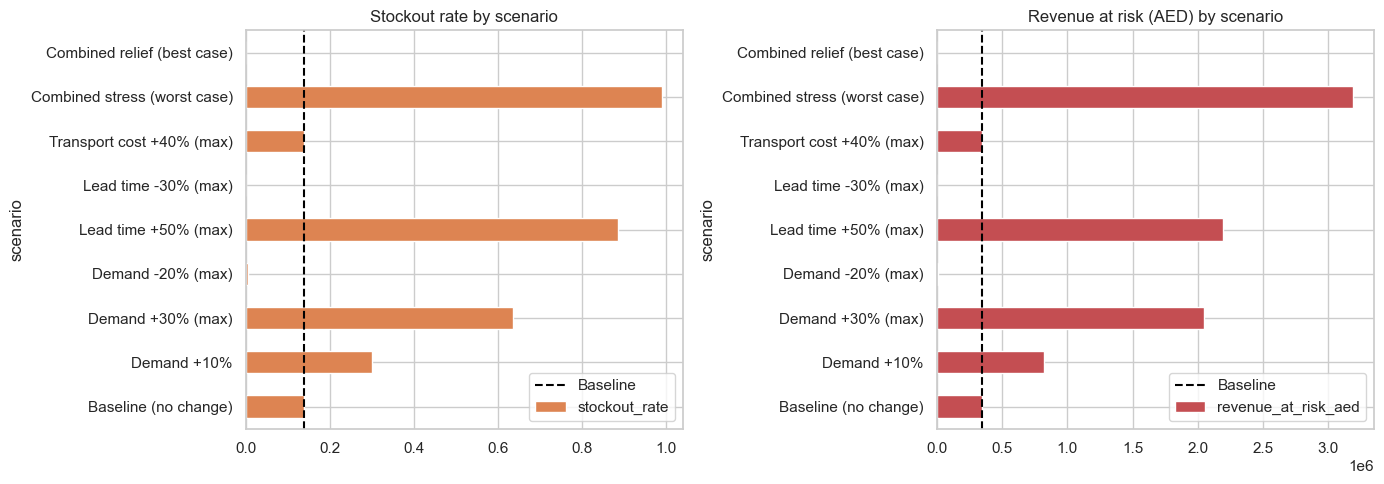

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison['stockout_rate'].plot(kind='barh', ax=axes[0], color='C1')
axes[0].axvline(comparison.loc['Baseline (no change)', 'stockout_rate'], color='black', linestyle='--', label='Baseline')
axes[0].set_title('Stockout rate by scenario')
axes[0].legend()

comparison['revenue_at_risk_aed'].plot(kind='barh', ax=axes[1], color='C3')
axes[1].axvline(comparison.loc['Baseline (no change)', 'revenue_at_risk_aed'], color='black', linestyle='--', label='Baseline')
axes[1].set_title('Revenue at risk (AED) by scenario')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Reading this: why the swings look large

The model calibrates its safety-stock level so that a 0%-change scenario reproduces the real observed baseline stockout rate exactly (see `engine.py`'s docstring) — it doesn't assume a well-buffered operation, it measures the one that actually exists. That baseline stockout rate is already double digits (thin buffer), so a combined demand+lead-time increase pushes required coverage well past a *fixed* safety stock quickly — the sharp jump in the combined-stress scenario is a real property of *this* operation's current buffer, not a modeling artifact. That's an actionable finding in itself: this supply chain has little slack against simultaneous demand growth and slower delivery.

## 4. Save results

In [5]:
from pathlib import Path

out_dir = Path('../reports/scenario_analysis')
out_dir.mkdir(parents=True, exist_ok=True)
comparison.to_csv(out_dir / 'scenario_comparison.csv')
(out_dir / 'scenario_comparison.md').write_text(
    '# Scenario Comparison\n\n' + comparison.reset_index().to_markdown(index=False) + '\n',
    encoding='utf-8',
)
print(f'Saved to {out_dir.resolve()}')

Saved to E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\reports\scenario_analysis
